# Motion models and Kalman filter

In [10]:
# Imports
import numpy as np
from ex4_utils import kalman_step
import math
import matplotlib.pyplot as plt
import sympy as sp
from sympy.interactive.printing import init_printing
init_printing(use_unicode=False, wrap_line=False)

## Deriving the matrices

### Random walk

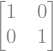

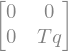

In [22]:
# Here we only use the random component
T_RW, q_RW = sp.symbols('T, q')
F_RW = sp.Matrix([[0,0],[0,0]])
Fi_RW = sp.exp(F_RW*T_RW)
display(Fi_RW)
L_RW = sp.Matrix([[0], [1]])
Q_RW = sp.integrate((Fi_RW * L_RW) * q_RW * (Fi_RW  * L_RW).T, (T_RW, 0, T_RW) )
display(Q_RW)
H = sp.Matrix([[1,0]])
display(H)

### Nearly constant velocity

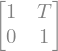

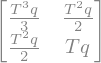

In [12]:
T_NCV, q_NCV = sp.symbols('T, q')
F_NCV = sp.Matrix([[0,1],[0,0]])
Fi_NCV = sp.exp(F_NCV*T_NCV)
display(Fi_NCV)
L_NCV = sp.Matrix([[0], [1]])
# The covariance matrix
Q_NCV = sp.integrate((Fi_NCV * L_NCV) * q_NCV * (Fi_NCV  * L_NCV).T, (T_NCV, 0, T_NCV) )
display(Q_NCV)

### Nearly constant acceleration

## Artificial tests

In [13]:
# Artificial tests
N = 40
v = np.linspace(5 * math.pi, 0, N)
x = np.cos(v) * v
y = np.sin(v) * v


def test_kalman(x,y, A, C, Q_i, R_i):
    sx = np.zeros((x.size,1), dtype=np.float32).flatten()
    sy = np.zeros((y.size, 1), dtype=np.float32).flatten()

    sx[0] = x[0]
    sy[0] = y[0]

    state = np.zeros((A.shape[0]), dtype=np.float32)
    state[0] = x[0]
    state[1] = y[0]
    covariance = np.eye(A.shape[0],  dtype=np.float32)

    for j in range(1, x.size):
        state, covariance, _ , _ = kalman_step(A, C, Q_i, R_i, 
                                               np.reshape(np.array([x[j], y[j]]),(-1,1))
                                               ,np.reshape(state, (-1,1)), covariance)
        sx[j] = state[0]
        sy[j] = state[1]



In [ ]:
Fi_NCV_np, Q_NCV_np, 

(array([[1., 1.],
        [0., 1.]]),
 array([[0.33333333, 0.5       ],
        [0.5       , 1.        ]]))

In [23]:
# Nearly constant velocity, input values into derived matrices
T = 1
q = 1
r = 1
Fi_NCV_np = Fi_NCV.evalf(subs={T_NCV:T, q_NCV:q})
Fi_NCV_np = np.array(Fi_NCV_np.tolist(), dtype=float)
Q_NCV_np = Q_NCV.evalf(subs={T_NCV:T, q_NCV: q})
Q_NCV_np = np.array(Q_NCV_np.tolist(), dtype=float)
H_np = np.array(H.tolist(), dtype=float)
# Define also the observation covariance 
R = r * np.array([[1,0], [0,1]]) 
test_kalman(x,y,Fi_NCV_np, H_np, Q_NCV_np, R)  

 

(1, 2) (2, 1)


LinAlgError: Incompatible dimensions